# **TDA Tutorial**

[Reference] 

- Tutorial TDA code:
https://github.com/postech-minds/postech-minds/blob/main/tutorials/%5BGTDA_TUTO%5D01-Introduction_to_TDA.ipynb

- Gif - 0D:
https://giotto-ai.github.io/gtda-docs/0.4.0/_images/persistent_homology_0d.gif

- Gif - 1D:
https://giotto-ai.github.io/gtda-docs/0.4.0/_images/persistent_homology_1d.gif

!pip install giotto-tda 

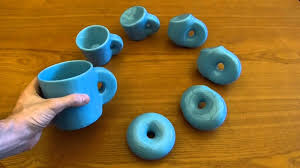

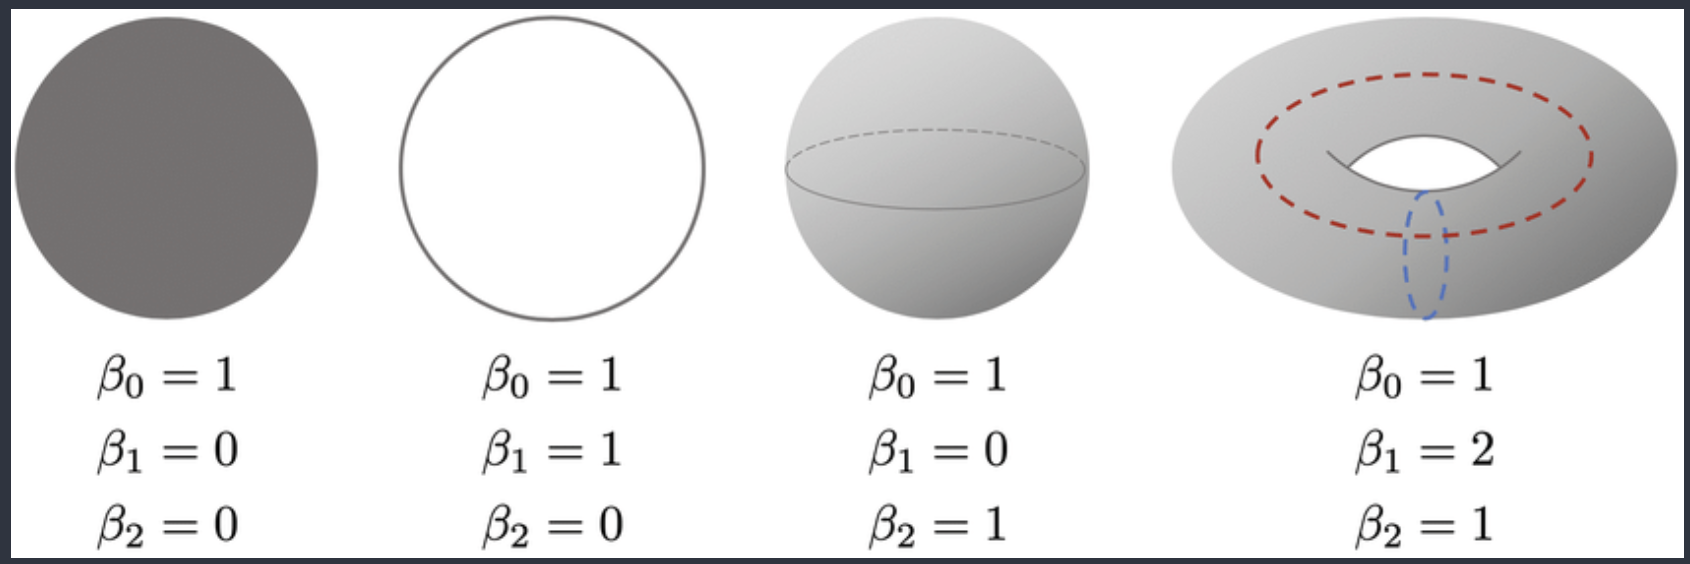

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


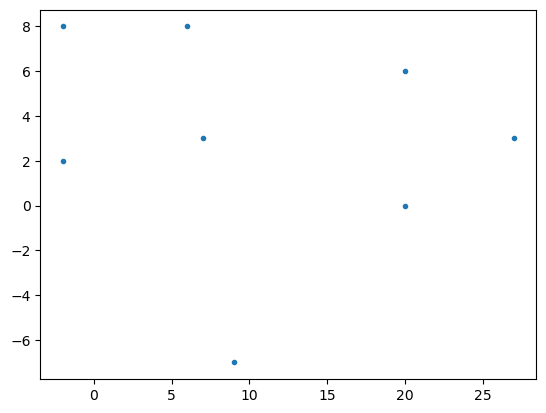

In [1]:
import numpy as np
import matplotlib.pyplot as plt

point_cloud = np.array([[-2.0,8.0],
                        [6.0,8.0],
                        [-2.0,2.0],
                        [7.0,3.0],
                        [27.0, 3.0],
                        [20.0,6.0],
                        [20.0,0.0],
                        [9.0,-7.0]
                        ])

plt.plot(point_cloud[:,0], point_cloud[:,1], '.')

In [2]:
from gtda.plotting import plot_point_cloud
plot_point_cloud(point_cloud)

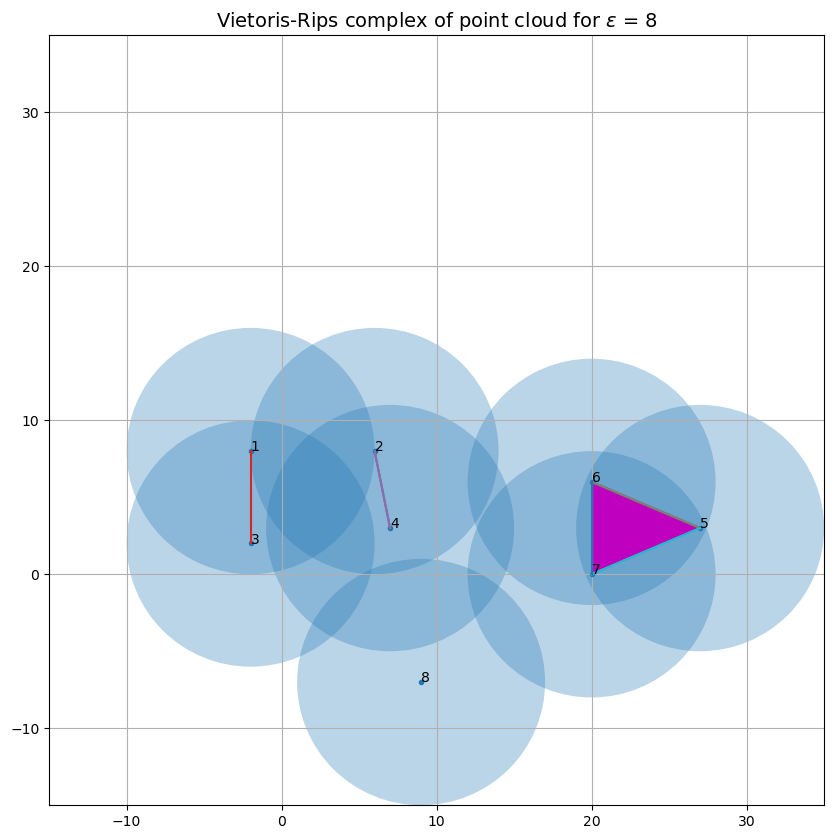

In [3]:
## Visualize Vietoris-Rips Complex

from matplotlib.patches import Circle,Polygon

epsilon = 8     # distance parameter
m = len(point_cloud)    # the number of points in given point cloud
adj_mat = np.zeros((m,m))

## Assume that the metric for our point cloud is Euclidean distance.
def Euclidean_distance(x,y):
    norm = np.dot(x-y,x-y)
    return np.sqrt(norm)

plt.figure(figsize=(10,10))
## Step 1. For each point p, draw a circle with radius epsilon and center p
plt.plot(point_cloud[:,0], point_cloud[:,1], '.')
for i in range(0,len(point_cloud)):
    plt.gca().add_patch(Circle(point_cloud[i], radius = epsilon, alpha = 0.3))
    plt.annotate(f'{i+1}',(point_cloud[i]))


## Step 2. If the distance between two points x and y is less than epsilon, connect two points with edge.
for x,i in zip(point_cloud,np.arange(m)):
    for y,j in zip(point_cloud,np.arange(m)):
        if 0 < Euclidean_distance(x,y) < epsilon:
            plt.plot([x[0],y[0]],[x[1],y[1]],'-')
            adj_mat[i,j] = 1
            adj_mat[j,i] = 1


## Step 3. If three edges consist of a triangle, fill in the face of the triangle.
for i in range(0,m):
    for j in range(0,m):
        for k in range(0,m):
            if (adj_mat[i,j] == 1) & (adj_mat[j,k] == 1) & (adj_mat[k,i] == 1):
                plt.gca().add_patch(Polygon((point_cloud[i],point_cloud[j],point_cloud[k]), facecolor = 'm'))

plt.title(f'Vietoris-Rips complex of point cloud for $\epsilon$ = {epsilon}', fontsize = 14)
plt.xlim(np.min(point_cloud)-epsilon,np.max(point_cloud)+epsilon)
plt.ylim(np.min(point_cloud)-epsilon,np.max(point_cloud)+epsilon)
plt.grid()

In [4]:
## Visualize Vietoris-Rips Complex

from matplotlib.patches import Circle,Polygon



def Visualize_VRC(point_cloud, epsilon):
    epsilon = epsilon     # distance parameter
    m = len(point_cloud)    # the number of points in given point cloud
    adj_mat = np.zeros((m,m))

    ## Assume that the metric for our point cloud is Euclidean distance.

    
    plt.figure(figsize=(10,10))
    ## Step 1. For each point p, draw a circle with radius epsilon and center p
    plt.plot(point_cloud[:,0], point_cloud[:,1], '.')
    for i in range(0,len(point_cloud)):
        plt.gca().add_patch(Circle(point_cloud[i], radius = epsilon, alpha = 0.3))
        plt.annotate(f'{i+1}',(point_cloud[i]))


    ## Step 2. If the distance between two points x and y is less than epsilon, connect two points with edge.
    for x,i in zip(point_cloud,np.arange(m)):
        for y,j in zip(point_cloud[i:],np.arange(i,m)):
            if 0 < Euclidean_distance(x,y) < epsilon:
                plt.plot([x[0],y[0]],[x[1],y[1]],'-')
                adj_mat[i,j] = 1
                adj_mat[j,i] = 1


    ## Step 3. If three edges consist of a triangle, fill in the face of the triangle.
    for i in range(0,m):
        for j in range(0,m):
            for k in range(0,m):
                if (adj_mat[i,j] == 1) & (adj_mat[j,k] == 1) & (adj_mat[k,i] == 1):
                    plt.gca().add_patch(Polygon((point_cloud[i],point_cloud[j],point_cloud[k]), facecolor = 'm'))
    
    plt.title(f'Vietoris-Rips complex of point cloud for $\epsilon$ = {epsilon}', fontsize = 14)
    plt.xlim(np.min(point_cloud)-1,np.max(point_cloud)+1)
    plt.ylim(np.min(point_cloud)-1,np.max(point_cloud)+1)
    plt.grid()

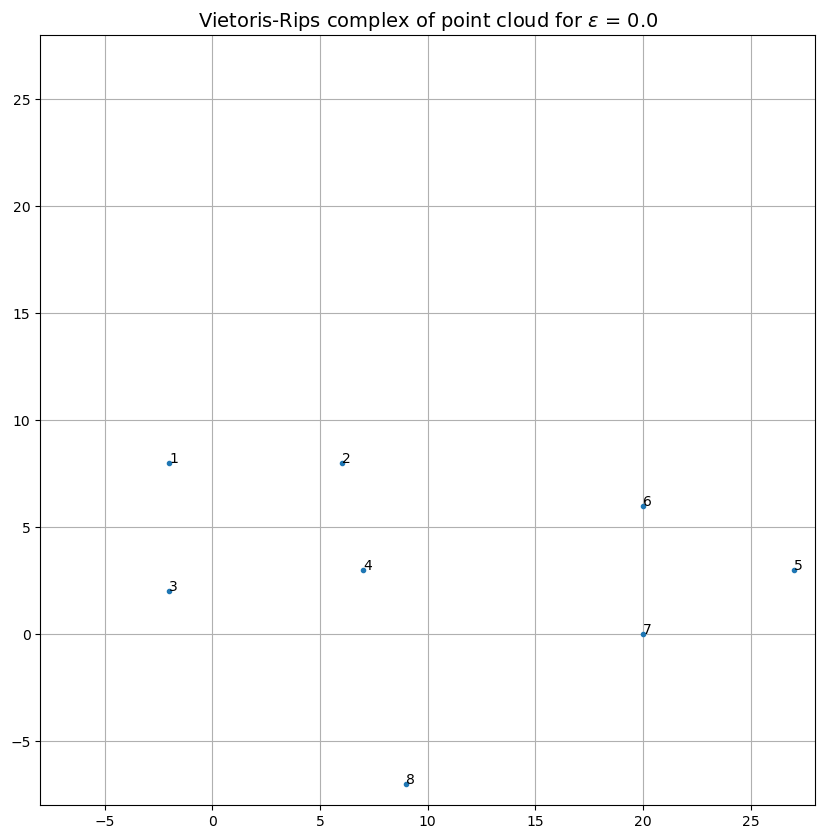

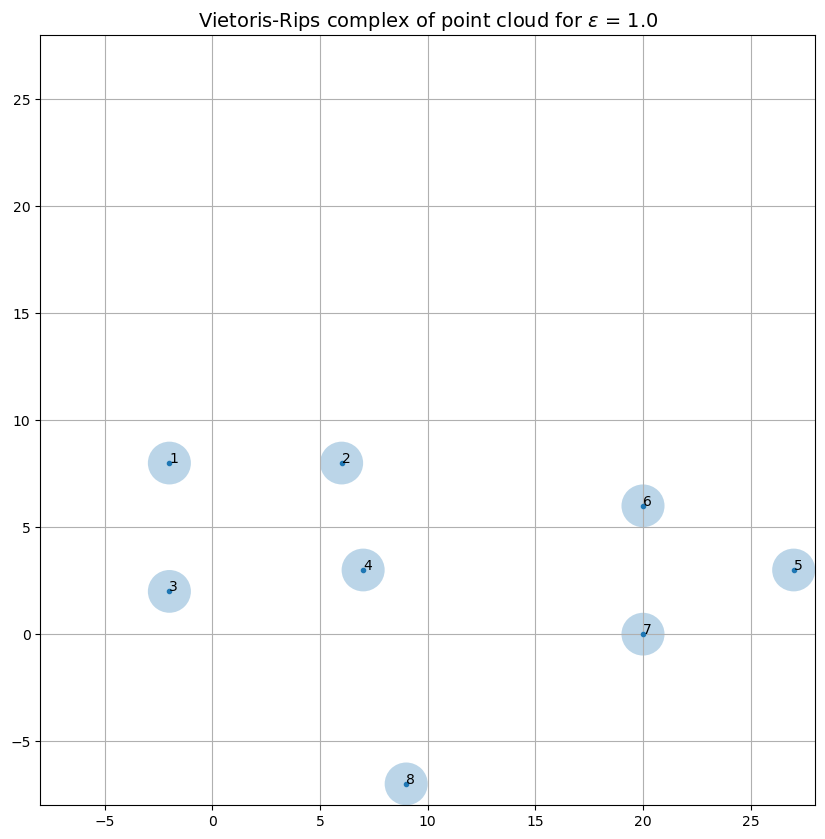

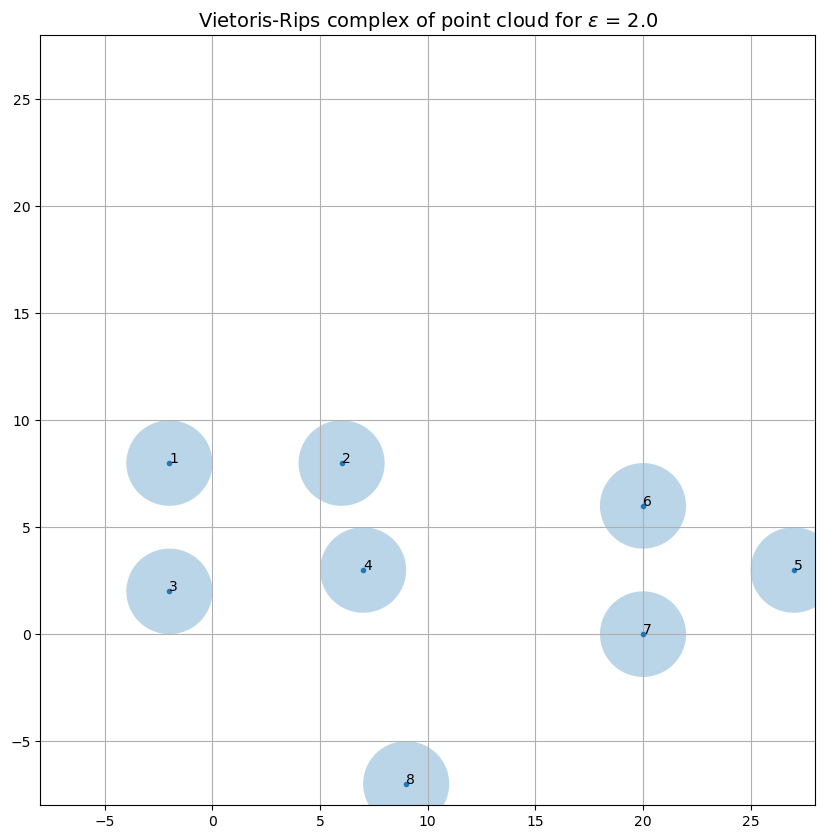

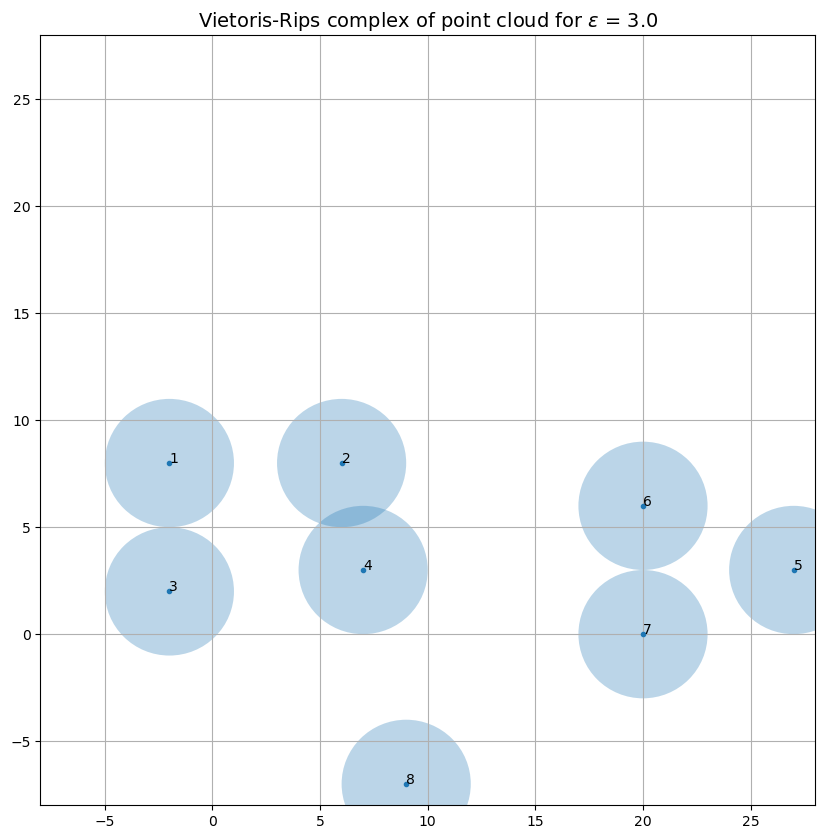

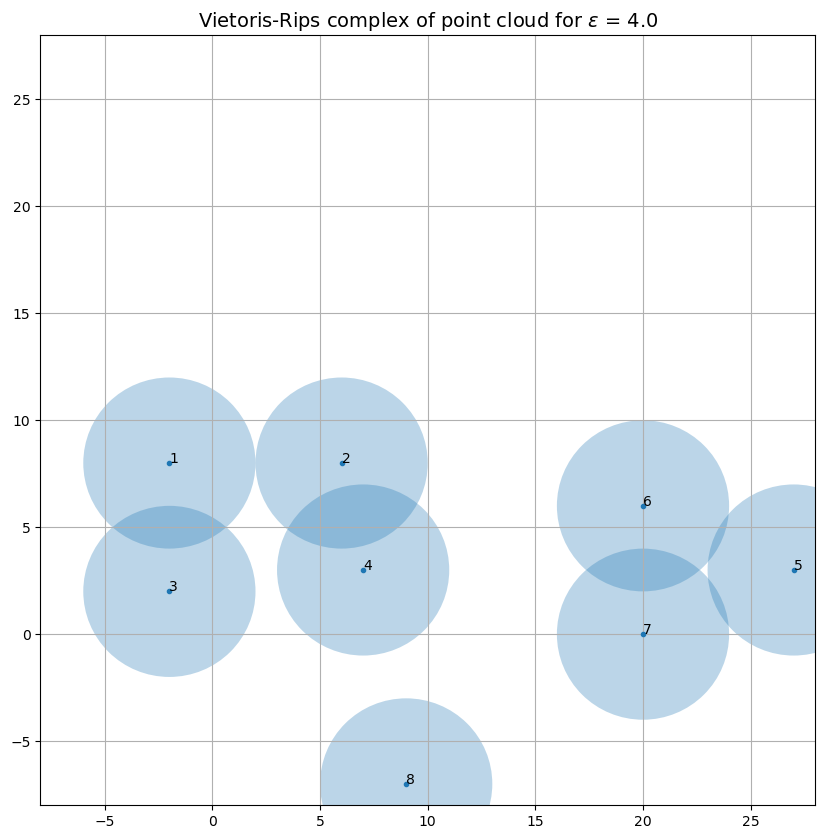

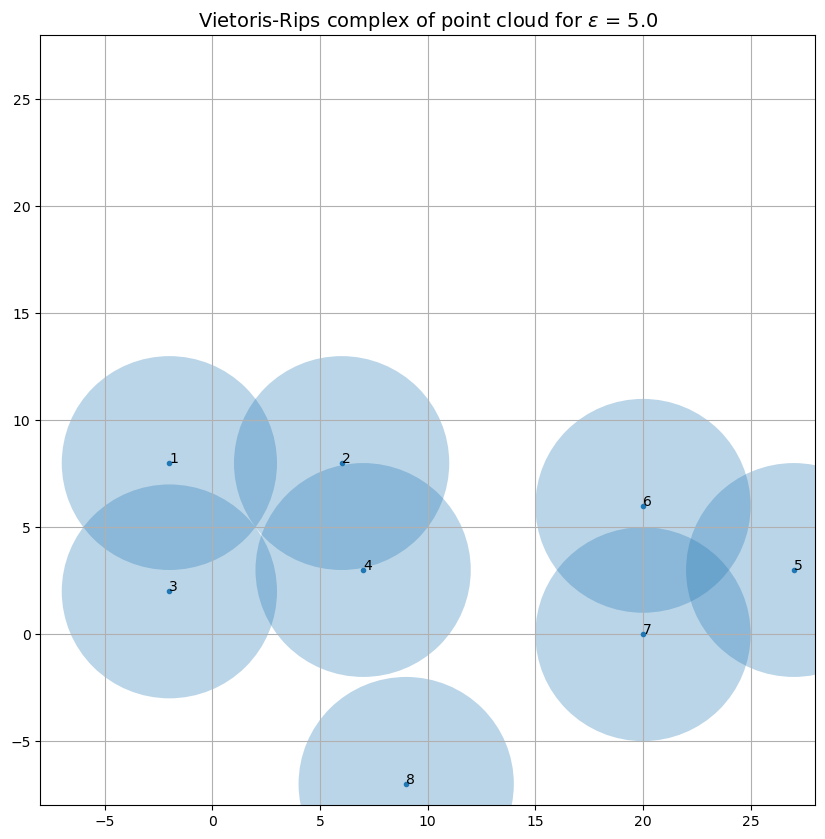

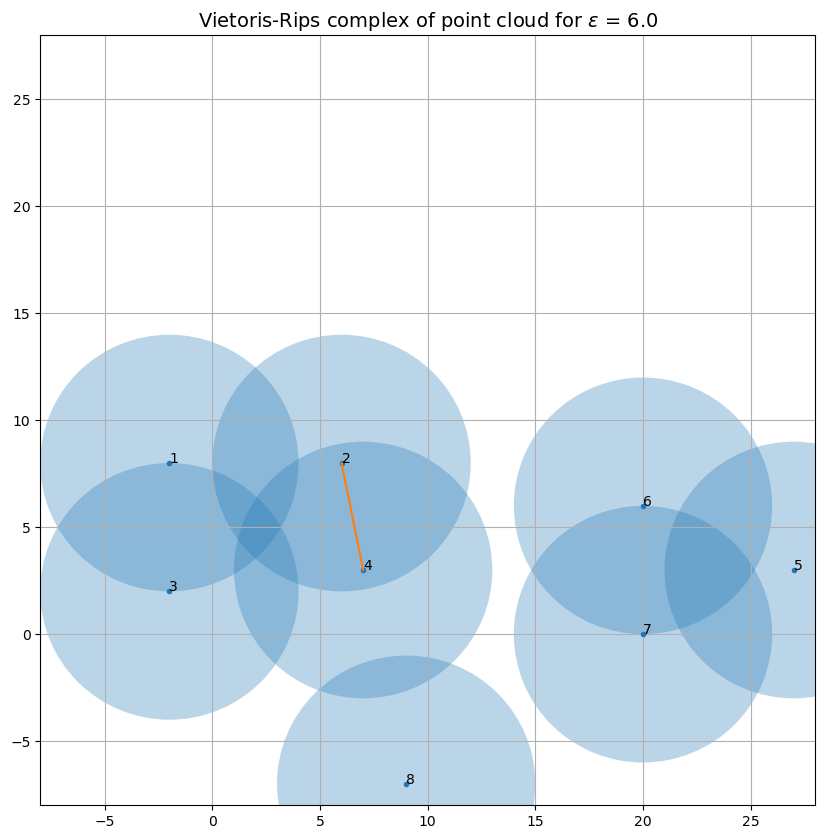

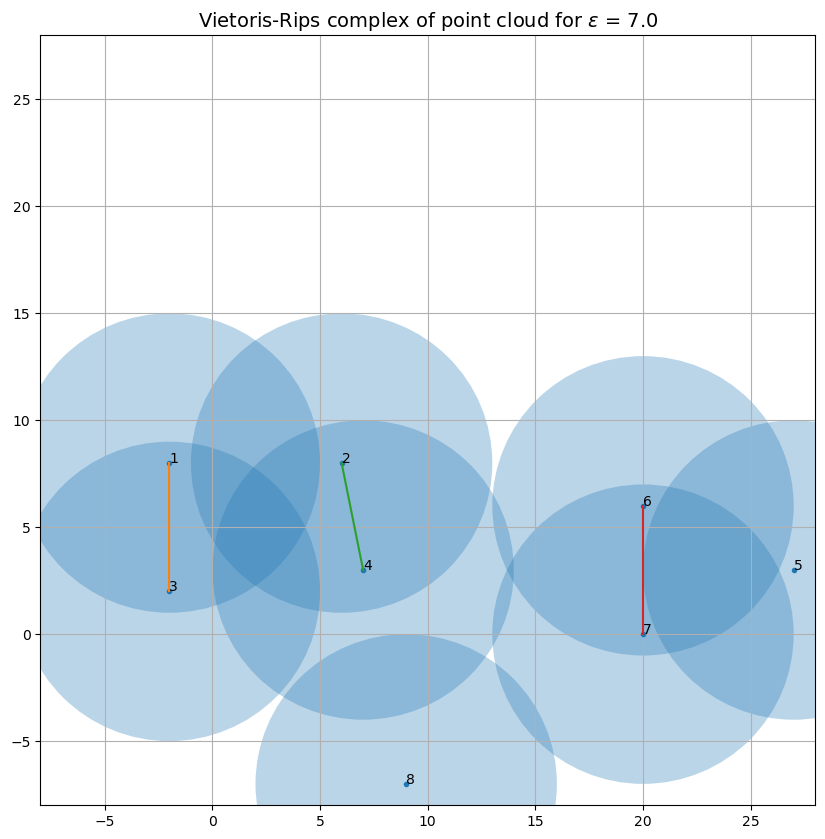

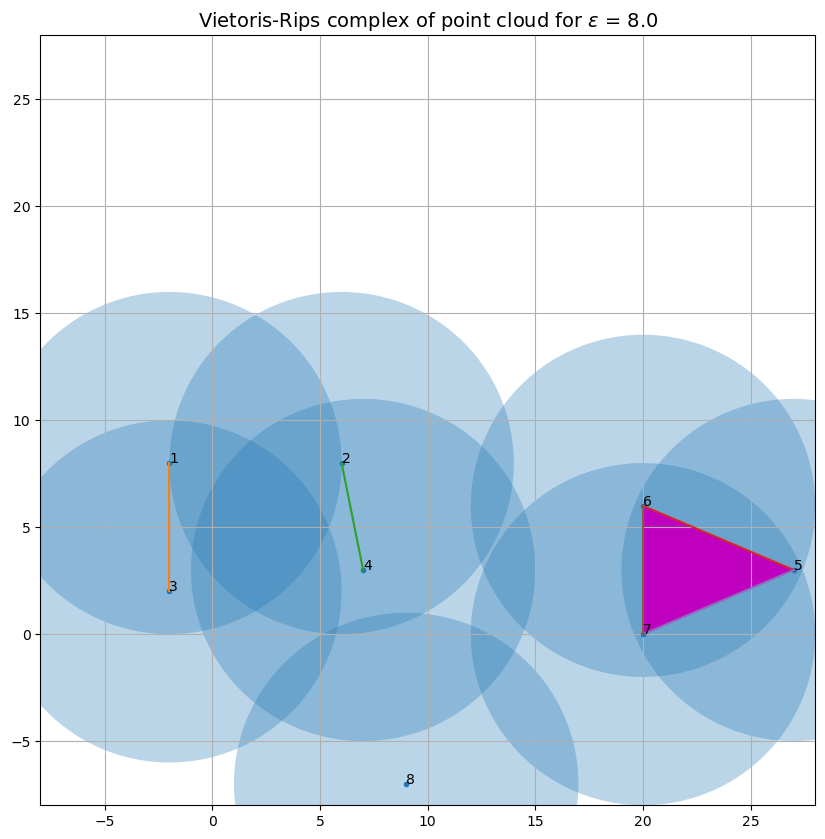

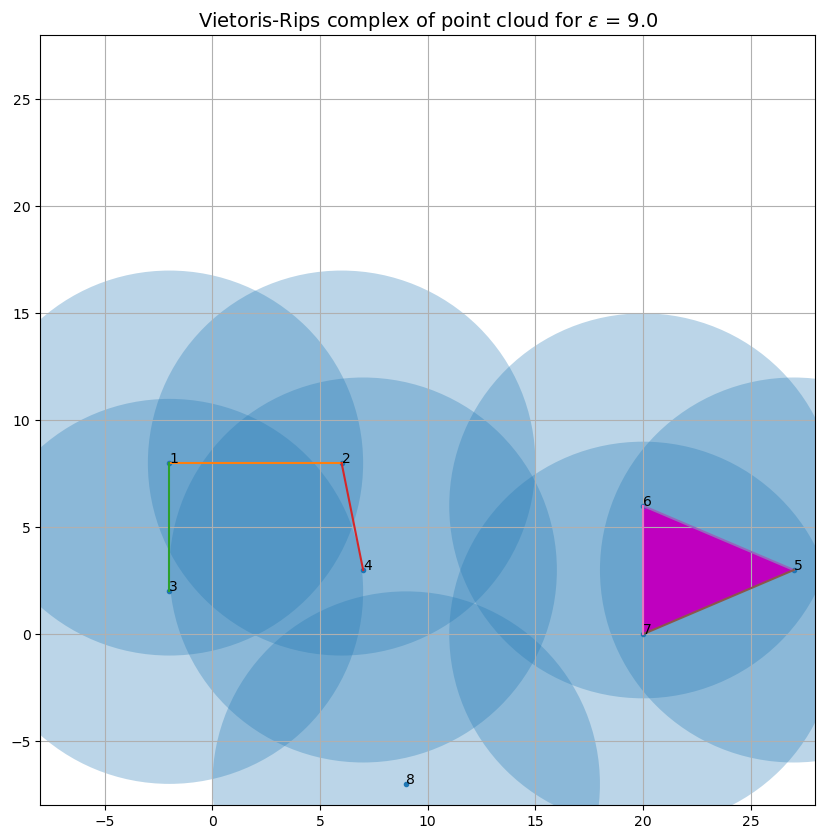

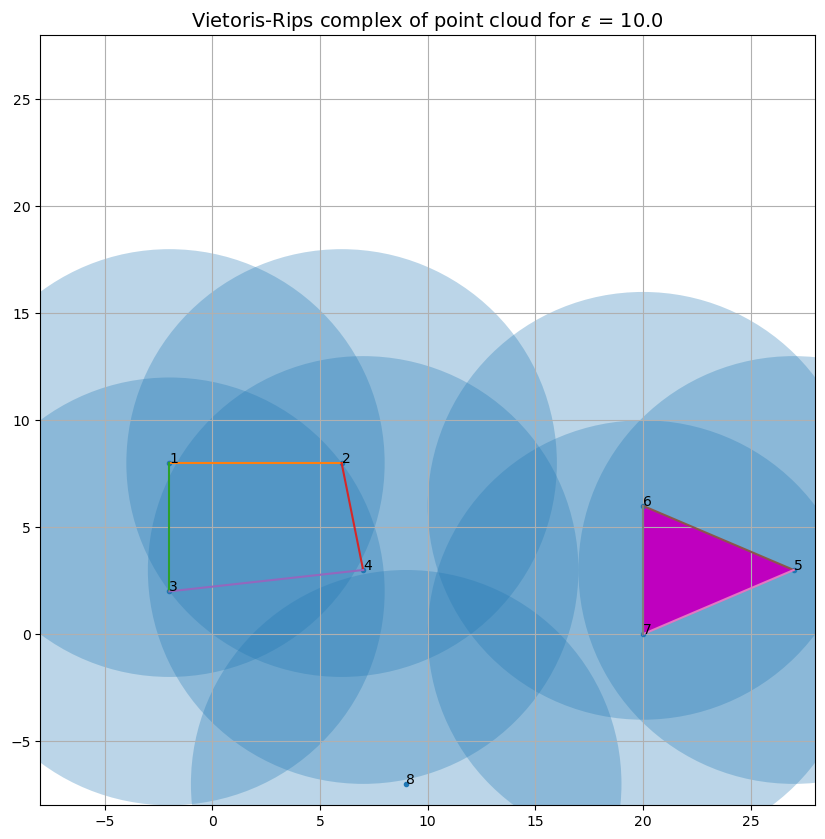

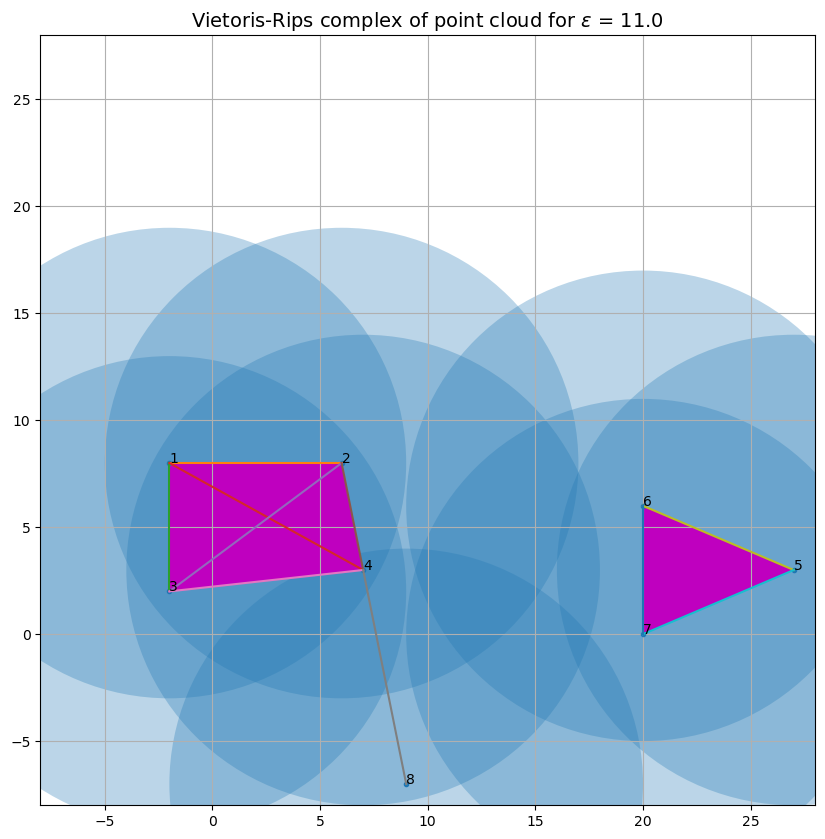

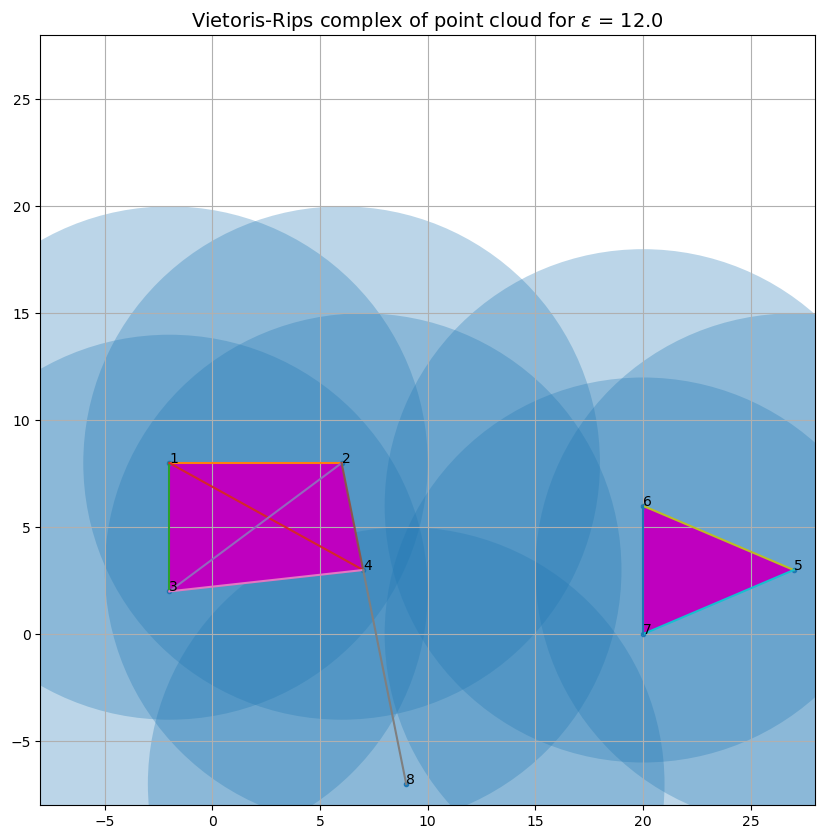

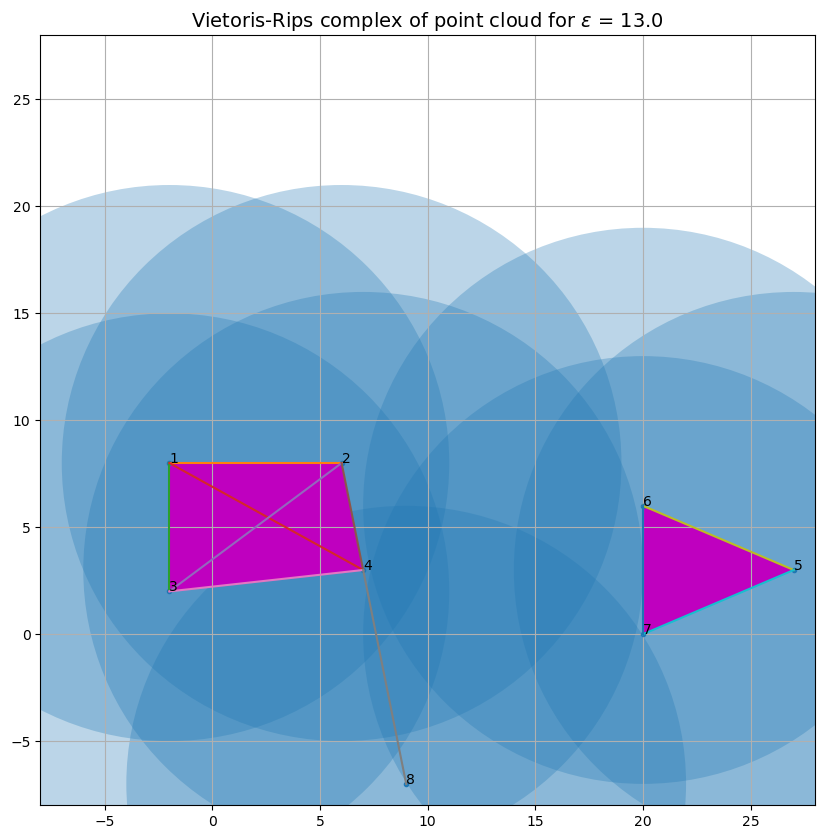

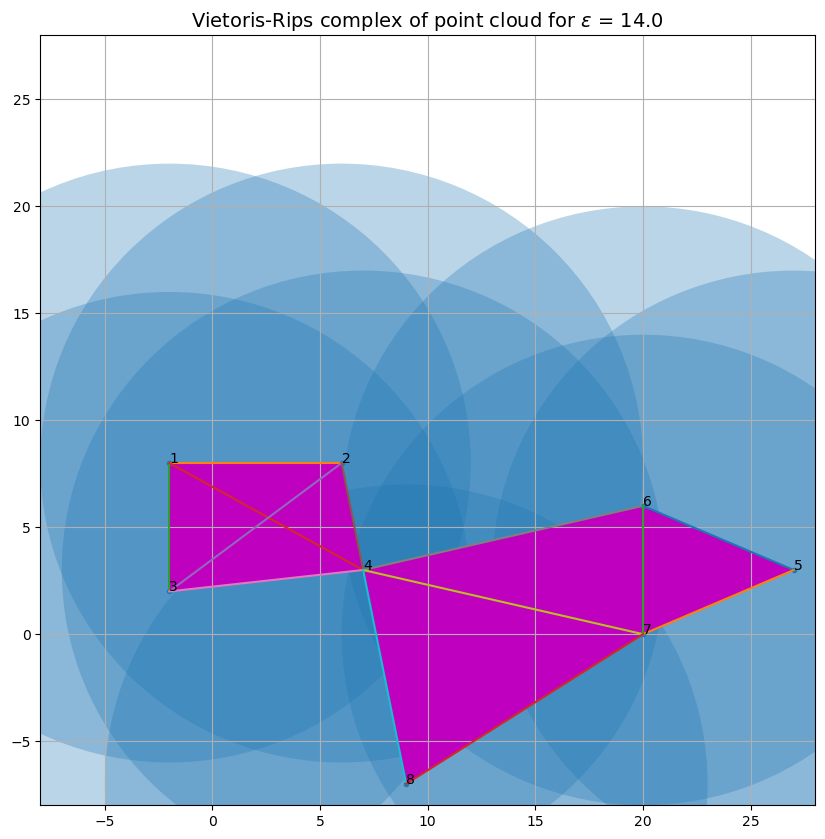

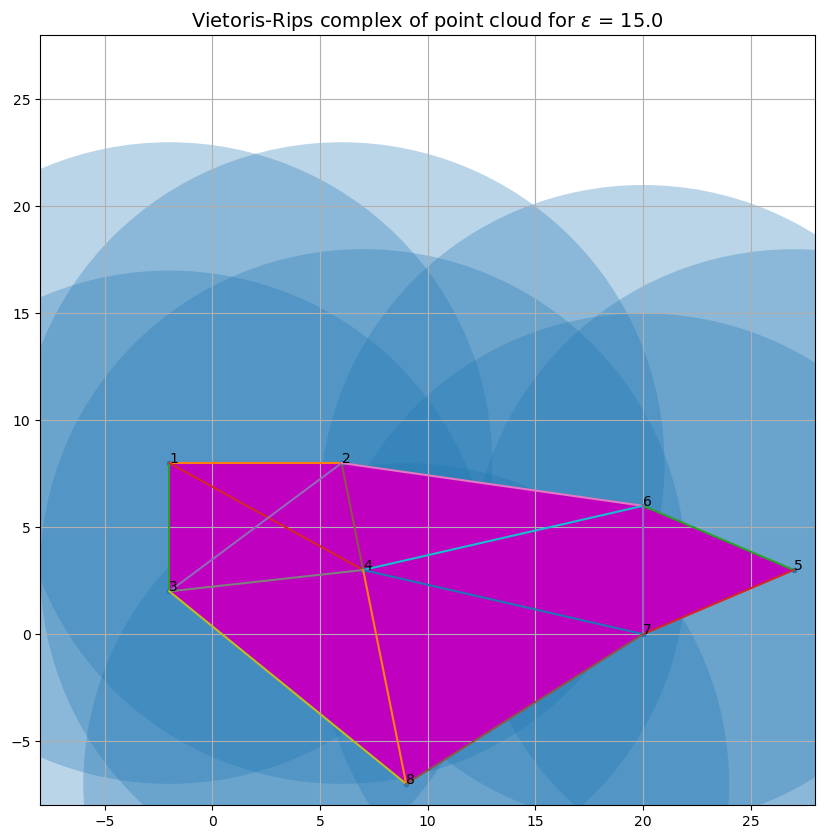

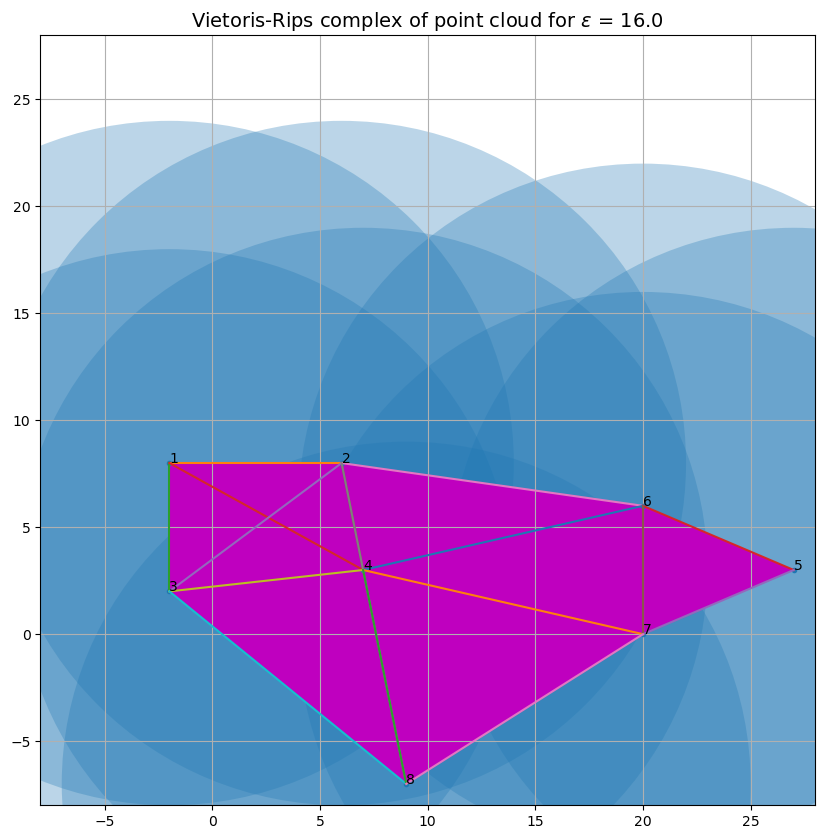

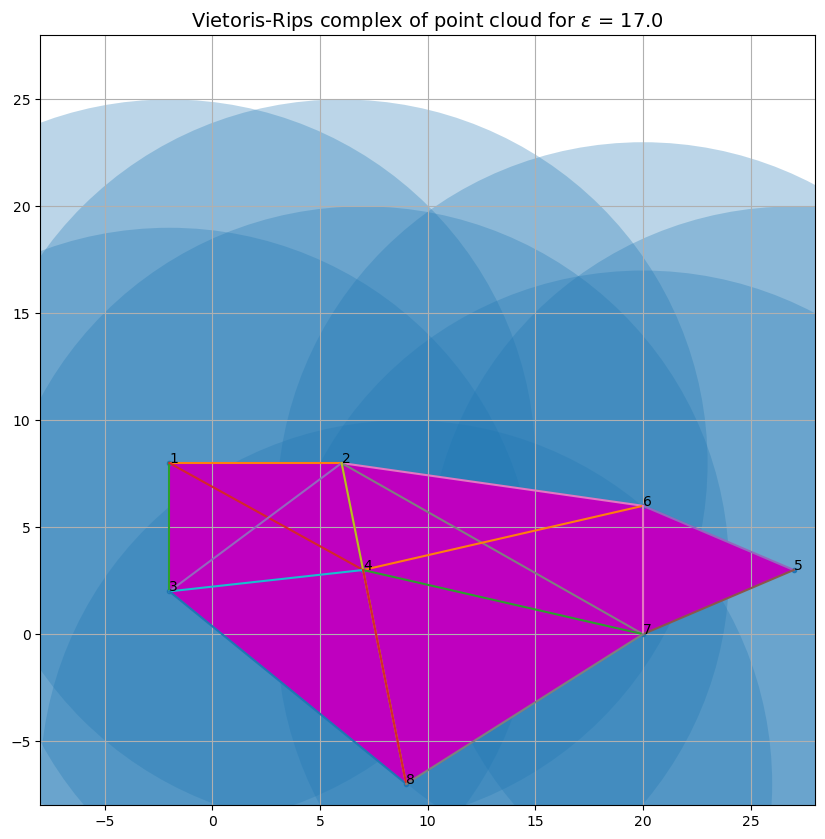

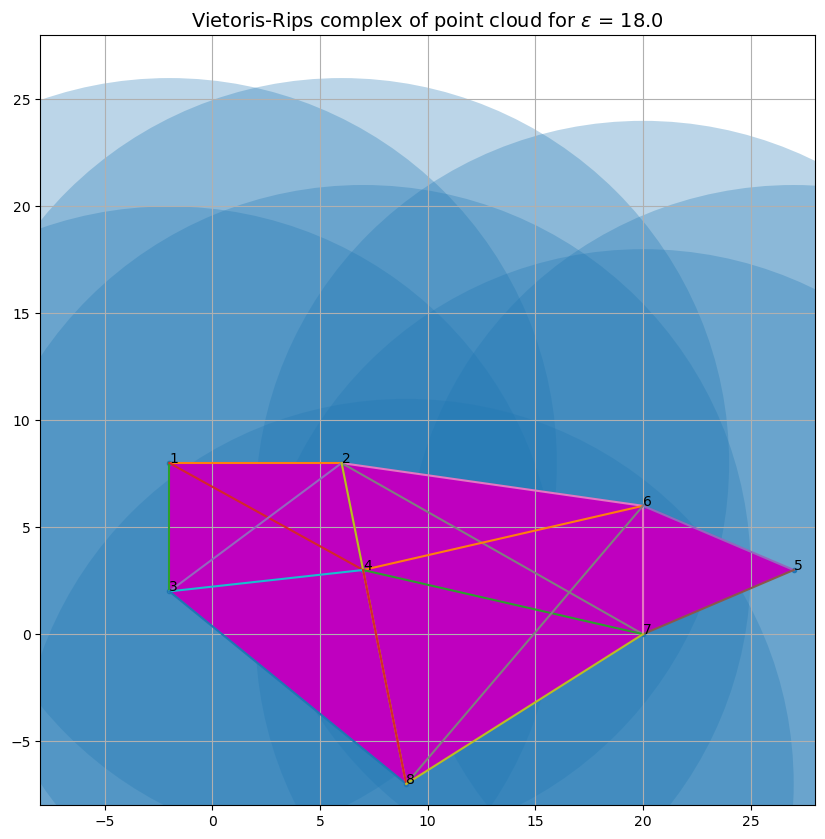

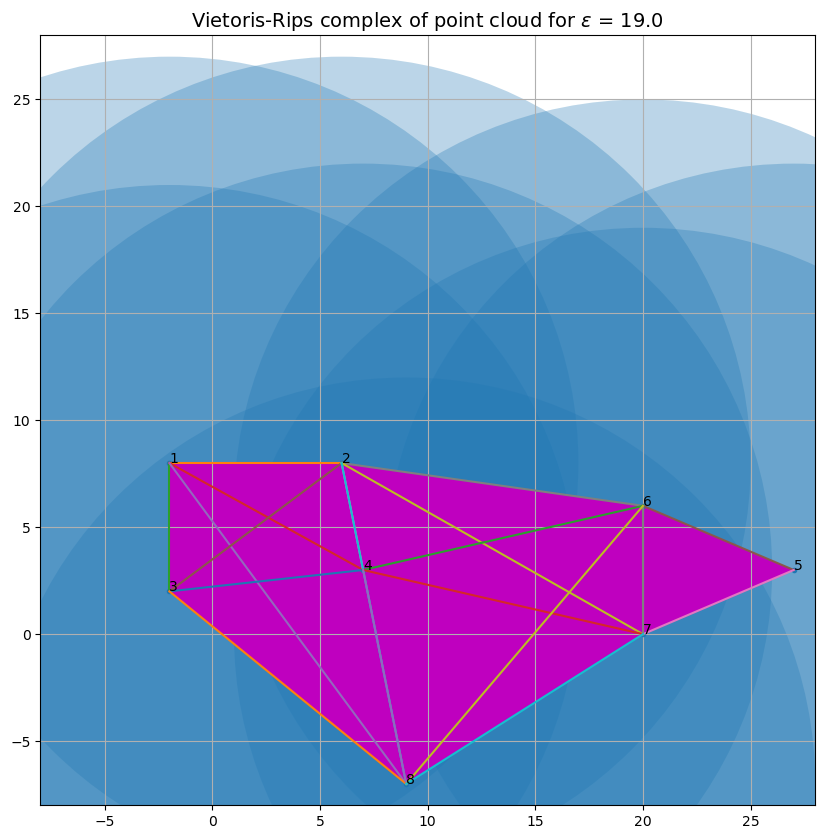

In [5]:
from pylab import *
%matplotlib inline

e = np.linspace(0,19,20)

for e in e:
    Visualize_VRC(point_cloud, e)


---

### 먼저 거리 계산 (관련 쌍만)

| 엣지 | 계산 | 거리 |
|------|------|------|
| P2–P4 | √((7-6)²+(3-8)²) = √26 | **5.099** |
| P1–P3 | √((−2−(−2))²+(2-8)²) = 6 | **6.000** |
| P6–P7 | √((20-20)²+(0-6)²) = 6 | **6.000** |
| P5–P6 | √((20-27)²+(6-3)²) = √58 | **7.616** |
| P1–P2 | √((6−(−2))²+(8-8)²) = 8 | **8.000** |
| P3–P4 | √((7−(−2))²+(3-2)²) = √82 | **9.055** |
| P2–P3 | √((−2-6)²+(2-8)²) = 10 | **10.000** |
| P4–P8 | √((9-7)²+(−7-3)²) = √104 | **10.198** |
| P7–P8 | √((9-20)²+(−7-0)²) = √170 | **13.038** |

---

### PD 테이블

| Birth | Death | Dim | 연결하는 엣지 | 의미 (어떤 이벤트) |
|-------|-------|-----|--------------|-------------------|
| 0 | **5.099** | H₀ | **P2–P4** | {P2}와 {P4} 처음 합쳐짐 |
| 0 | **6.000** | H₀ | **P1–P3** | {P1}와 {P3} 처음 합쳐짐 |
| 0 | **6.000** | H₀ | **P6–P7** | {P6}와 {P7} 처음 합쳐짐 |
| 0 | **7.616** | H₀ | **P5–P6** | {P5}가 {P6,P7}에 합류 |
| 0 | **8.000** | H₀ | **P1–P2** | {P1,P3}와 {P2,P4} 합쳐짐 |
| 0 | **10.198** | H₀ | **P4–P8** | {P1,P2,P3,P4}와 {P8} 합쳐짐 |
| 0 | **13.038** | H₀ | **P7–P8** | {P5,P6,P7}와 나머지 전체 합쳐짐 |
| 0 | **∞** | H₀ | — | 마지막 살아남은 1개 성분 (essential) |
| **9.055** | **10.000** | H₁ | 루프: **P1–P2–P4–P3–P1** | 사각형 루프 탄생 → 소멸 |

---

ε=0에서 시작하면 점 8개가 각자 **별개의 섬**입니다.

```
{P1}  {P2}  {P3}  {P4}  {P5}  {P6}  {P7}  {P8}   ← β₀ = 8
```

ε≈5.099에서 P2–P4 엣지가 추가되면:

```
{P1}  {P2, P4}  {P3}  {P5}  {P6}  {P7}  {P8}   ← β₀ = 7
```

→ **{P2}와 {P4}라는 두 섬이 합쳐져서 하나의 섬이 됨**  
→ 섬 하나가 사라짐 = **H₀ 성분 하나 소멸** → death = 5.099

---

### 읽는 법 요약

- **H₀** death값 = "이 두 점이 처음으로 연결됐을 때의 거리" = 두 클러스터를 잇는 최단 엣지의 길이
- **H₁** birth = 9.055 = P3–P4 엣지가 추가되어 사각형 루프 완성, death = 10.0 = P2–P3 대각선이 추가되어 삼각형으로 루프 소멸


---

## **H₁ (루프)**

---

### 점들 사이 거리 계산

```python
point_cloud = [P1=(-2,8), P2=(6,8), P3=(-2,2), P4=(7,3), ...]
```

| 엣지 | 거리 |
|------|------|
| P2–P4 | √26 ≈ **5.10** |
| P1–P3 | 6 = **6.00** |
| P1–P2 | 8 = **8.00** |
| P3–P4 | √82 ≈ **9.06** |
| **P2–P3 (대각선)** | **10.00** |
| **P1–P4 (대각선)** | √106 ≈ **10.30** |

---

### ε = 10.0 일 때 (코드 조건: `d < epsilon`, strict)

- P2–P3 (d=10.0) → **포함 안 됨** (d < 10이 아니라 d = 10이므로)
- P1–P4 (d≈10.30) → 포함 안 됨

```
P1 ── P2
|      |
P3 ── P4
```

4개 점이 **사각형 테두리**만 형성 → 내부를 채울 삼각형 없음 → **빈 사각형**

이 빈 루프가 바로 **H₁ 특징** (1차원 구멍)입니다.

---

### ε = 11.0 일 때

- P2–P3 (d=10.0 < 11) → **포함됨** ← 이게 핵심!
- P1–P4 (d≈10.30 < 11) → 포함됨

이제 두 대각선이 생기면서 삼각형 4개가 모두 형성:
- △(P1,P2,P3), △(P1,P2,P4), △(P1,P3,P4), △(P2,P3,P4)

→ Step 3의 `Polygon`이 채워짐 → **속이 채워진 사각형**

---

### β₀ vs H₁ 무엇이 달라지나?

| | ε=10 | ε=11 |
|--|------|------|
| **β₀** | **변화 없음** (1) | **변화 없음** (1) |
| **β₁** | **1** (루프 살아있음) | **0** (루프 소멸) |

β₀는 두 경우 모두 동일합니다. P1,P2,P3,P4는 이미 ε≈9.06에서 하나로 연결되어 있거든요. 달라지는 건 오직 **H₁**입니다.

---

### 이게 바로 PD 결과에 정확히 나타납니다

노트북 하단의 PD 계산 결과를 보면:
```python
[ 9.05538559, 10.  ,  1.  ]   ← dimension=1, 즉 H₁
```

- **Birth = 9.055** : ε≈9.06일 때 P3–P4 엣지가 추가되며 사각형 루프 완성 → 구멍 탄생
- **Death = 10.0** : ε=10.0일 때 대각선 P2–P3 추가 → 삼각형이 구멍을 채움 → 소멸
- **Persistence = 10.0 − 9.055 ≈ 0.945**

그래서 ε=10 그림에서 빈 사각형이 보이는 것은 정확히 이 H₁ feature가 **아직 살아있는 상태**를 보여주는 것이고, ε=11에서 채워지는 건 이 feature가 **소멸한 상태**를 보여주는 겁니다.

In [6]:
## Example. Persistent diagram
from gtda.homology import VietorisRipsPersistence           #Vietoris-Rips complex를 사용해 PD를 얻는 변환기입니다. 
from gtda.plotting import plot_diagram                      #plotly를 이용해 PD를 보여주는 기능입니다.

VR = VietorisRipsPersistence(homology_dimensions = [0,1],   # 먼저 VietorisRipsPersistence 변환기를 정의합니다.
                             reduced_homology=False)        # reduced_homology 변수는 처음부터 끝까지 존재하는 연결성분을 무시할 것인지 정하는 파라미터입니다.

PD = VR.fit_transform(point_cloud[None, :, :])              # 변환기에 point_cloud를 [None, :, :] 쉐입으로 학습/변환 하면 PD를 얻을 수 있습니다.
PD


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


array([[[ 0.        ,  5.09901953,  0.        ],
        [ 0.        ,  6.        ,  0.        ],
        [ 0.        ,  6.        ,  0.        ],
        [ 0.        ,  7.6157732 ,  0.        ],
        [ 0.        ,  8.        ,  0.        ],
        [ 0.        , 10.19803905,  0.        ],
        [ 0.        , 13.03840446,  0.        ],
        [ 0.        ,         inf,  0.        ],
        [ 9.05538559, 10.        ,  1.        ]]])

In [7]:
## Plot persistent diagram

plot_diagram(PD[0])

# PD가 아닌 PD[0]을 입력하는 이유는 
# 변환기 VietorisRipsPersistence가 여러 개의 포인트 클라우드를 변환하면 여러 개의 Persistent diagram의 리스트로 저장하기 때문인데,
# 우리는 하나의 포인트 클라우드를 변환했기에, 리스트 PD의 유일한 첫 번째 원소가 실제 Persistent diagram이기 때문입니다.

In [8]:
## Normal distribution으로부터 생성된 Point cloud
import numpy as np
point_cloud1 = np.random.randn(200,2)
point_cloud1.shape

(200, 2)

In [9]:
## Plot point cloud1
from gtda.plotting import plot_point_cloud

plot_point_cloud(point_cloud1)

In [10]:
## Circle 형태를 띈 데이터로부터 생성된 Point cloud
rand_angles = 2*np.pi*np.random.rand(200)       # 랜덤하게 각을 200개 뽑습니다.
rand_noise = np.random.rand(200,1)         # 구간 [0,1]에서 200개의 랜덤한 노이즈를 생성합니다.
circle1 = np.array([np.cos(rand_angles[:100])+0.5,np.sin(rand_angles[:100])]).T    # 중심이 (0.05,0)인 원에서 랜덤하게 100개의 점을 추출합니다.
circle2 = np.array([np.cos(rand_angles[100:])-0.5,np.sin(rand_angles[100:])]).T    # 중심이 (-0.05,0)인 원에서 랜덤하게 100개의 점을 추출합니다.
point_cloud2 = rand_noise*np.vstack((circle1,circle2))  # 위 점들을 모두 합친 뒤, 각각에 노이즈를 적용합니다.
plot_point_cloud(point_cloud2)


In [11]:
from gtda.homology import VietorisRipsPersistence

VR = VietorisRipsPersistence(homology_dimensions = [0,1])
point_clouds = [point_cloud1, point_cloud2]  # VietorisRipsPersistence 변환기는 한번에 여러 개의 포인트클라우드를 변환시킬 수 있습니다.
diagrams = VR.fit_transform(point_clouds)    # 이때 diagrams는 PD의 리스트로, 입력한 포인트 클라우드의 순서에 대응하는 PD가 들어있습니다.
diagrams.shape  # 2개의 포인트 클라우드를 입력했기 때문에 2개의 PD를 가지고 있고, 각각은 비교하기 좋게 (n,3) 사이즈로 통일되어 저장됩니다.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


(2, 244, 3)

In [12]:
from gtda.plotting import plot_diagram
plot_diagram(diagrams[0])

In [13]:
plot_diagram(diagrams[1])

## *Move to Key Note*